<a href="https://www.kaggle.com/code/lalit7881/house-price-prediction-dataset-eda?scriptVersionId=312975570" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/miadul/house-price-prediction-dataset/house_price_50k.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/miadul/house-price-prediction-dataset/house_price_50k.csv")

In [3]:
df.head()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
0,1360,6,2,2,9,10,0,0,1,0,1,0,1,0,6.939333,7242,premium,low,5.952493e+05
1,4272,5,2,3,24,8,1,0,0,1,1,1,1,0,0.400918,7729,low,low,1.571208e+06
2,3592,1,4,3,4,20,0,1,1,1,0,1,0,1,6.292386,1081,premium,mid,1.379943e+06
3,966,5,2,2,6,14,1,0,0,0,0,1,1,0,8.964112,8912,medium,low,4.367819e+05
4,4926,4,3,1,18,9,0,0,0,0,1,0,1,1,2.843309,8146,low,mid,1.792425e+06


In [4]:
df.tail()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,location,income_level,price
49995,733,1,4,1,23,23,0,0,1,0,0,1,1,1,1.699633,2188,premium,mid,3.386262e+05
49996,3420,4,1,3,9,13,1,1,1,0,0,0,1,1,9.451960,7273,low,low,1.185043e+06
49997,2218,3,1,2,3,6,0,1,1,0,1,0,0,1,8.659219,9856,medium,mid,8.443978e+05
49998,992,2,4,3,26,20,1,0,0,0,0,0,1,0,6.343849,2858,premium,low,3.796953e+05
49999,3782,1,2,2,5,13,1,0,0,1,1,1,0,0,5.254151,8465,premium,high,1.450285e+06


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density 

In [6]:
df.describe()

,area,bedrooms,bathrooms,floors,age,distance,garage,parking,garden,security,school_nearby,hospital_nearby,shopping_mall_nearby,public_transport,crime_rate,population_density,price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,5.000000e+04
mean,2752.970540,3.496040,2.498040,1.997060,19.573740,14.968700,0.500540,0.497300,0.500280,0.496220,0.501100,0.498320,0.498320,0.500040,5.006444,5065.94598,1.030261e+06
std,1297.148134,1.712146,1.117704,0.815368,11.552502,8.363714,0.500005,0.499998,0.500005,0.499991,0.500004,0.500002,0.500002,0.500005,2.876776,2864.34322,4.580199e+05
min,500.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000311,100.00000,9.090069e+04
25%,1630.000000,2.000000,1.000000,1.000000,10.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.523018,2575.00000,6.357375e+05
50%,2756.000000,3.000000,2.000000,2.000000,20.000000,15.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,5.022946,5060.50000,1.031763e+06
75%,3872.000000,5.000000,3.000000,3.000000,30.000000,22.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.479632,7543.00000,1.423102e+06
max,4999.000000,6.000000,4.000000,3.000000,39.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.999869,9999.00000,1.996474e+06


In [7]:
df.isnull().sum()

area                    0
bedrooms                0
bathrooms               0
floors                  0
age                     0
distance                0
garage                  0
parking                 0
garden                  0
security                0
school_nearby           0
hospital_nearby         0
shopping_mall_nearby    0
public_transport        0
crime_rate              0
population_density      0
location                0
income_level            0
price                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

area                      int64
bedrooms                  int64
bathrooms                 int64
floors                    int64
age                       int64
distance                  int64
garage                    int64
parking                   int64
garden                    int64
security                  int64
school_nearby             int64
hospital_nearby           int64
shopping_mall_nearby      int64
public_transport          int64
crime_rate              float64
population_density        int64
location                 object
income_level             object
price                   float64
dtype: object

In [10]:
df.shape

(50000, 19)

In [11]:
df.columns

Index(['area', 'bedrooms', 'bathrooms', 'floors', 'age', 'distance', 'garage',
       'parking', 'garden', 'security', 'school_nearby', 'hospital_nearby',
       'shopping_mall_nearby', 'public_transport', 'crime_rate',
       'population_density', 'location', 'income_level', 'price'],
      dtype='object')

In [12]:
df.nunique()

area                     4500
bedrooms                    6
bathrooms                   4
floors                      3
age                        40
distance                   29
garage                      2
parking                     2
garden                      2
security                    2
school_nearby               2
hospital_nearby             2
shopping_mall_nearby        2
public_transport            2
crime_rate              50000
population_density       9846
location                    3
income_level                3
price                   50000
dtype: int64

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area                  50000 non-null  int64  
 1   bedrooms              50000 non-null  int64  
 2   bathrooms             50000 non-null  int64  
 3   floors                50000 non-null  int64  
 4   age                   50000 non-null  int64  
 5   distance              50000 non-null  int64  
 6   garage                50000 non-null  int64  
 7   parking               50000 non-null  int64  
 8   garden                50000 non-null  int64  
 9   security              50000 non-null  int64  
 10  school_nearby         50000 non-null  int64  
 11  hospital_nearby       50000 non-null  int64  
 12  shopping_mall_nearby  50000 non-null  int64  
 13  public_transport      50000 non-null  int64  
 14  crime_rate            50000 non-null  float64
 15  population_density 

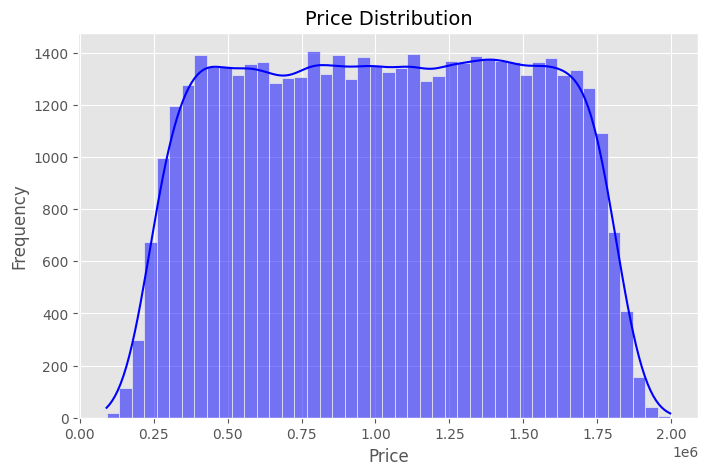

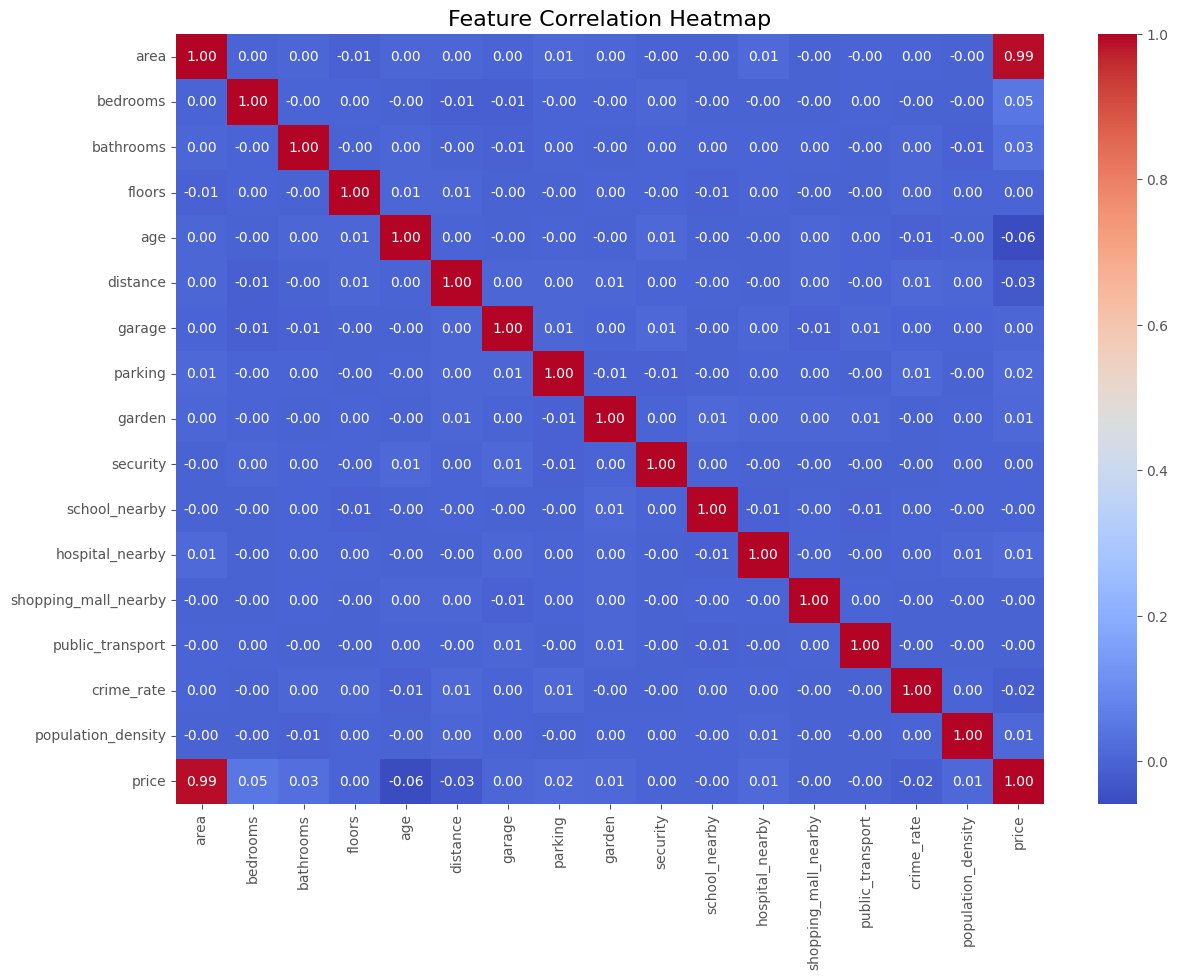

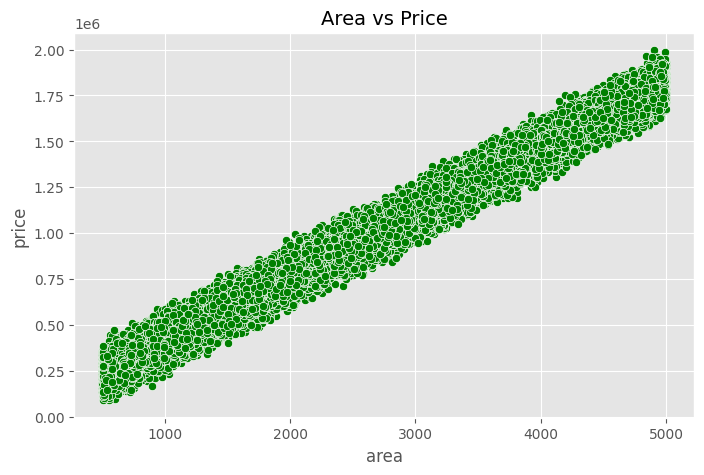

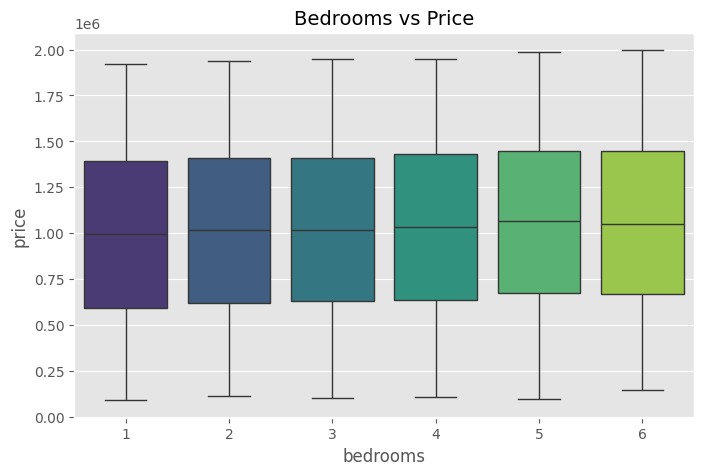

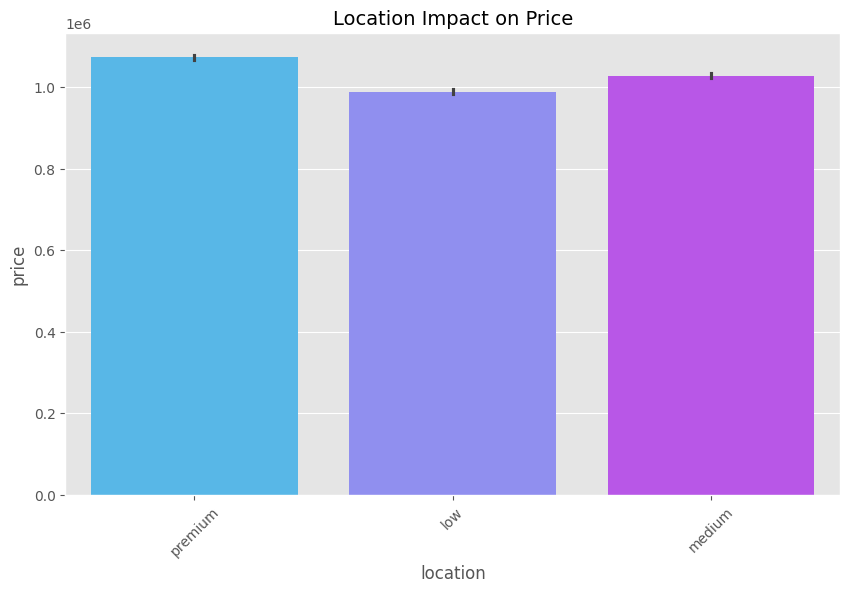

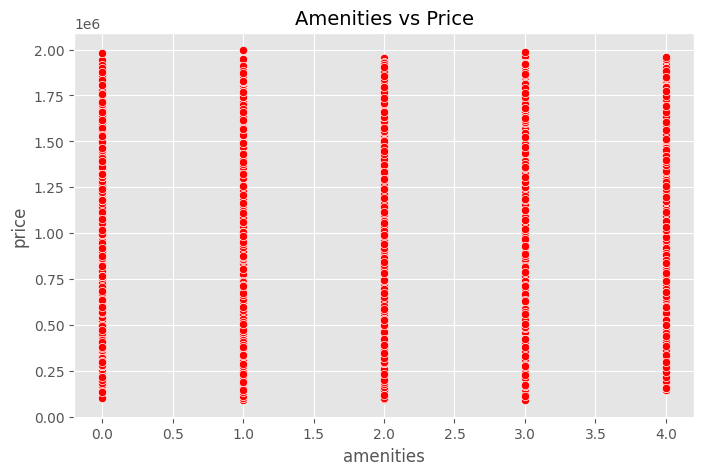

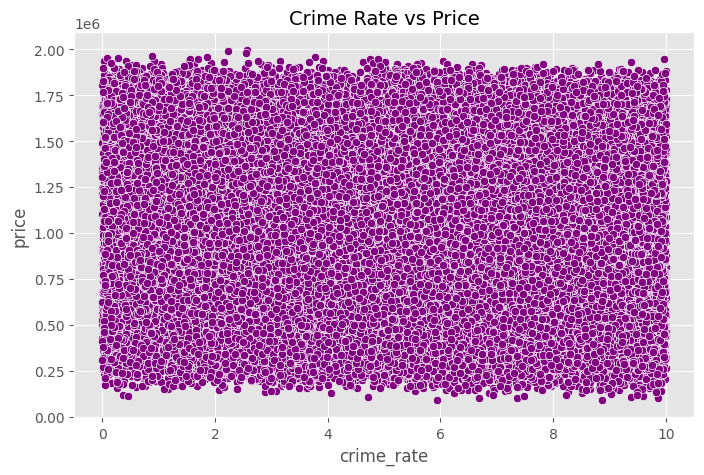

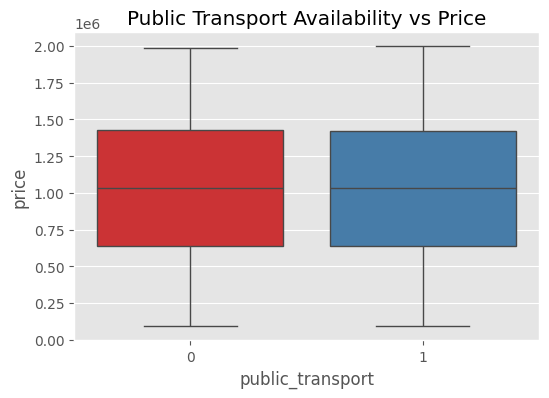

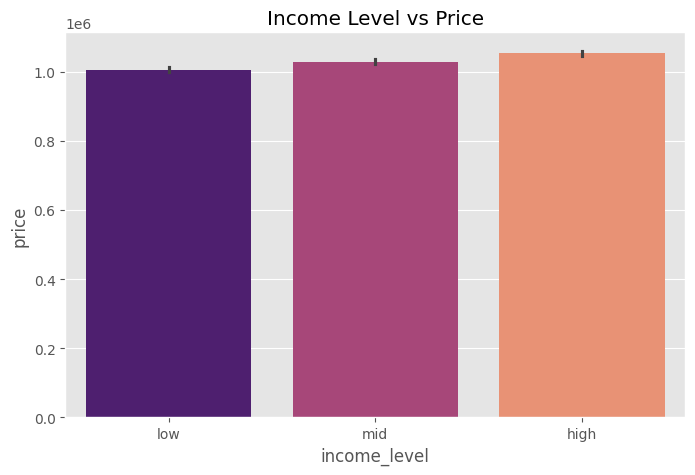

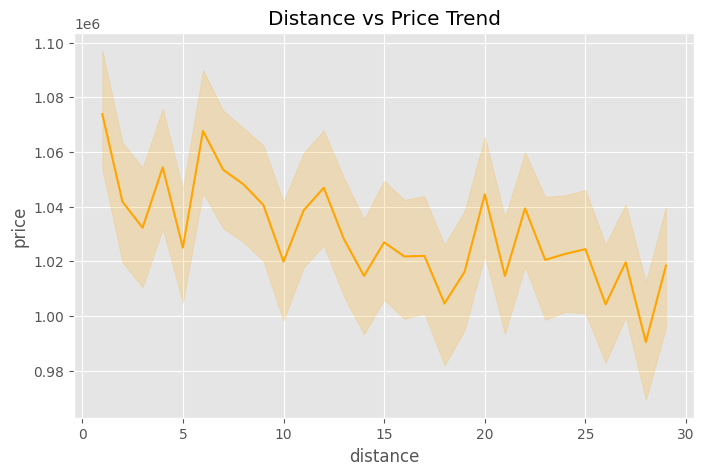

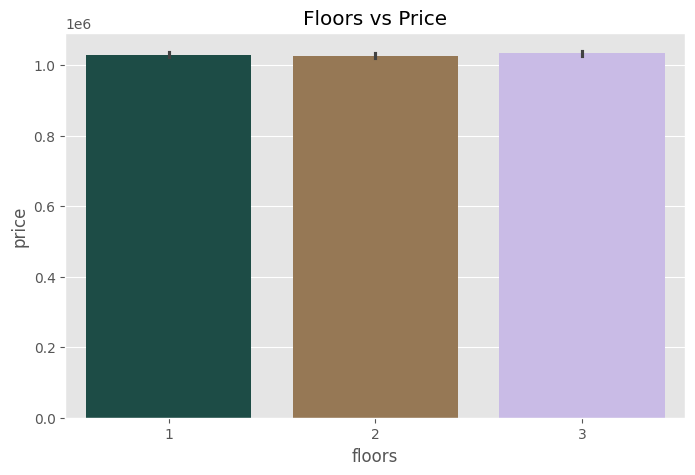

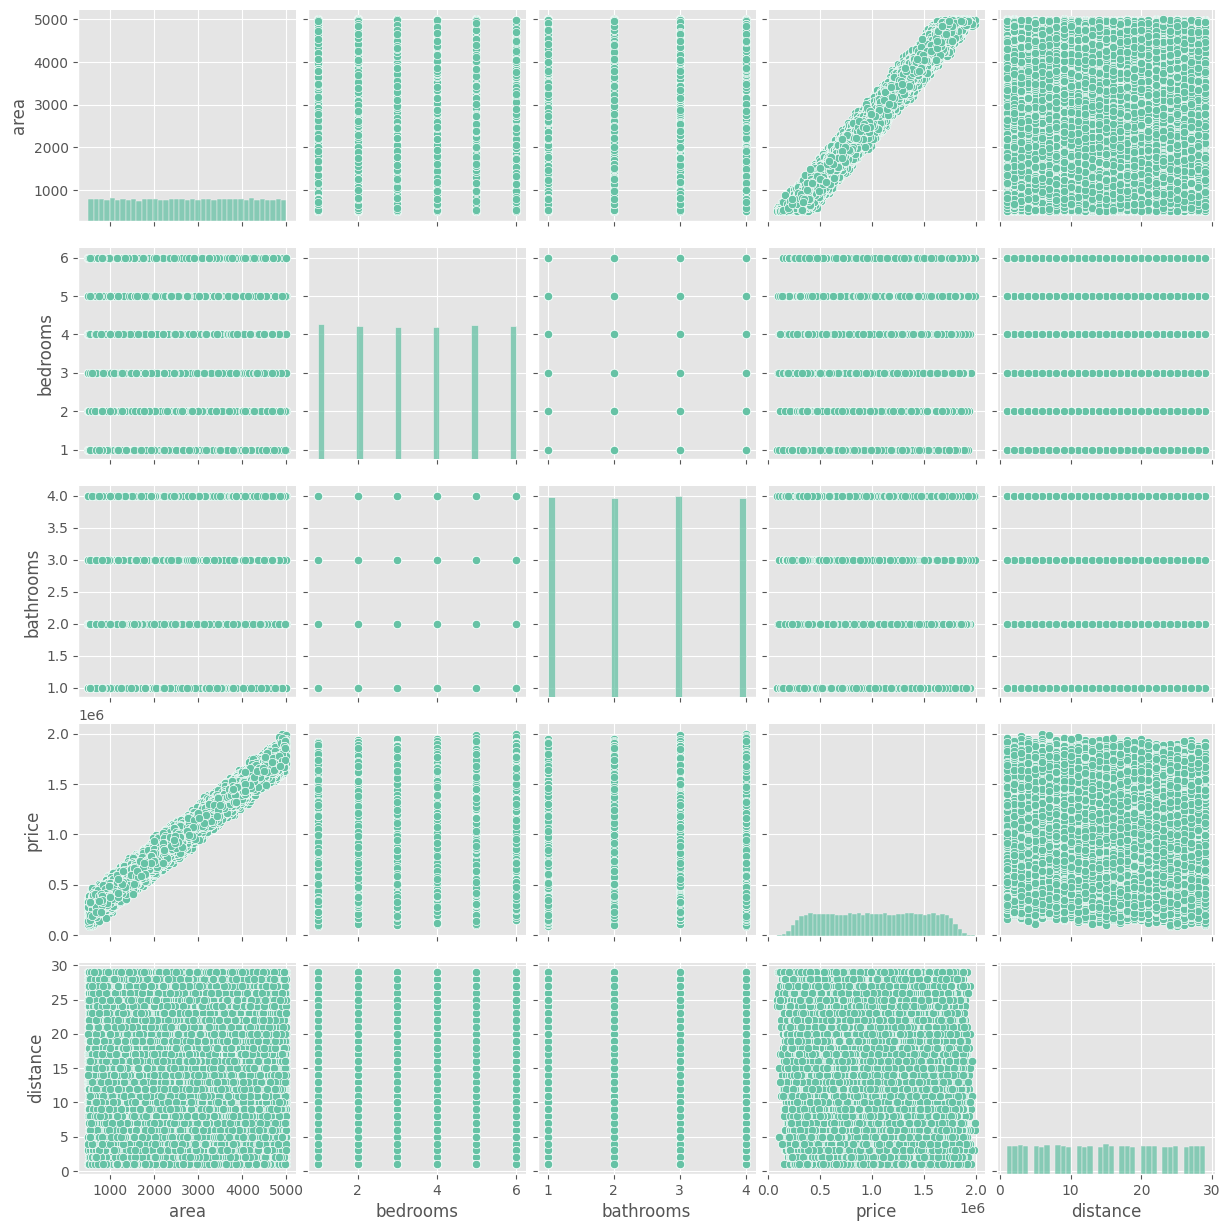

In [13]:
# ===============================
# STYLE SETTINGS
# ===============================
plt.style.use('ggplot')
sns.set_palette("Set2")  # colorful palette

# ===============================
# BASIC INFO
# ===============================
print(df.info())
print(df.describe())

# ===============================
# 1. PRICE DISTRIBUTION
# ===============================
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True, color='blue')
plt.title("Price Distribution", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# ===============================
# 2. CORRELATION HEATMAP
# ===============================
plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

# ===============================
# 3. AREA vs PRICE
# ===============================
plt.figure(figsize=(8,5))
sns.scatterplot(x='area', y='price', data=df, color='green')
plt.title("Area vs Price", fontsize=14)
plt.show()

# ===============================
# 4. BEDROOMS vs PRICE (BOXPLOT)
# ===============================
plt.figure(figsize=(8,5))
sns.boxplot(x='bedrooms', y='price', data=df, palette='viridis')
plt.title("Bedrooms vs Price", fontsize=14)
plt.show()

# ===============================
# 5. LOCATION vs PRICE
# ===============================
plt.figure(figsize=(10,6))
sns.barplot(x='location', y='price', data=df, palette='cool')
plt.xticks(rotation=45)
plt.title("Location Impact on Price", fontsize=14)
plt.show()

# ===============================
# 6. AMENITIES COUNT vs PRICE
# ===============================
df['amenities'] = df[['garage','parking','garden','security']].sum(axis=1)

plt.figure(figsize=(8,5))
sns.scatterplot(x='amenities', y='price', data=df, color='red')
plt.title("Amenities vs Price", fontsize=14)
plt.show()

# ===============================
# 7. CRIME RATE vs PRICE
# ===============================
plt.figure(figsize=(8,5))
sns.scatterplot(x='crime_rate', y='price', data=df, color='purple')
plt.title("Crime Rate vs Price", fontsize=14)
plt.show()

# ===============================
# 8. PUBLIC TRANSPORT IMPACT
# ===============================
plt.figure(figsize=(6,4))
sns.boxplot(x='public_transport', y='price', data=df, palette='Set1')
plt.title("Public Transport Availability vs Price")
plt.show()

# ===============================
# 9. INCOME LEVEL vs PRICE
# ===============================
plt.figure(figsize=(8,5))
sns.barplot(x='income_level', y='price', data=df, palette='magma')
plt.title("Income Level vs Price")
plt.show()

# ===============================
# 10. DISTANCE vs PRICE
# ===============================
plt.figure(figsize=(8,5))
sns.lineplot(x='distance', y='price', data=df, color='orange')
plt.title("Distance vs Price Trend")
plt.show()

# ===============================
# 11. FLOOR COUNT EFFECT
# ===============================
plt.figure(figsize=(8,5))
sns.barplot(x='floors', y='price', data=df, palette='cubehelix')
plt.title("Floors vs Price")
plt.show()

# ===============================
# 12. MULTI-VARIATE PAIRPLOT
# ===============================
sns.pairplot(df[['area','bedrooms','bathrooms','price','distance']], 
             palette='husl')
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.9901
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5000
           1       0.99      0.99      0.99      5000

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Decision Tree
Accuracy: 0.9757
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      5000
           1       0.98      0.97      0.98      5000

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


Random Forest
Accuracy: 0.9836
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      5000
           1       0.99      0.98      0.98      5000

    accuracy                           0.98     10000
   macro avg       0.98   

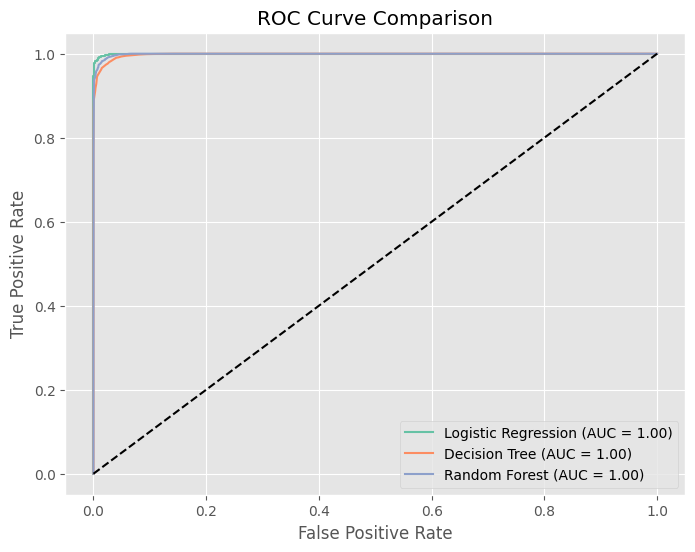


Model Accuracy Comparison:
Logistic Regression: 0.9901
Decision Tree: 0.9757
Random Forest: 0.9836

Best Model: Logistic Regression


In [14]:
# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

# ==============================
# 1. CREATE TARGET (CLASSIFICATION)
# ==============================
# Convert price into binary class: High (1) / Low (0)
median_price = df['price'].median()
df['target'] = (df['price'] > median_price).astype(int)

# Drop original price to avoid leakage
df = df.drop(columns=['price'])

# ==============================
# 2. FEATURES & TARGET
# ==============================
X = df.drop(columns=['target'])
y = df['target']

# Identify categorical & numerical columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

# ==============================
# 3. TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 4. PREPROCESSING (NO DATA LEAKAGE)
# ==============================
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# ==============================
# 5. MODELS
# ==============================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = {}

# ==============================
# 6. TRAIN + EVALUATE
# ==============================
plt.figure(figsize=(8,6))

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# ==============================
# 7. ROC CURVE PLOT
# ==============================
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==============================
# 8. MODEL COMPARISON
# ==============================
print("\nModel Accuracy Comparison:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

# Best Model
best_model = max(results, key=results.get)
print("\nBest Model:", best_model)

## Thank you...pls upvote!!!!!!!!!!